In [ ]:
import sys
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from src.data_loader import load_penguins_frame
penguins_df = load_penguins_frame()

In [4]:
penguins_df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [ ]:
penguins_df.tail(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
334,Chinstrap,Dream,50.2,18.8,202.0,3800.0,male,2009
335,Chinstrap,Dream,45.6,19.4,194.0,3525.0,female,2009
336,Chinstrap,Dream,51.9,19.5,206.0,3950.0,male,2009
337,Chinstrap,Dream,46.8,16.5,189.0,3650.0,female,2009
338,Chinstrap,Dream,45.7,17.0,195.0,3650.0,female,2009
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009
343,Chinstrap,Dream,50.2,18.7,198.0,3775.0,female,2009


<Axes: xlabel='flipper_length_mm', ylabel='bill_depth_mm'>

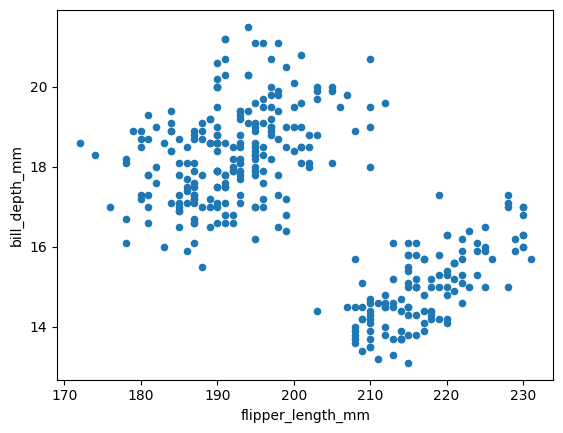

In [5]:
penguins_df.plot(kind = "scatter", x="flipper_length_mm", y="bill_depth_mm")

In [6]:
penguins_df[["bill_length_mm",
"bill_depth_mm",
"flipper_length_mm",
"body_mass_g"]].corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


array([[<Axes: title={'center': 'bill_length_mm'}>,
        <Axes: title={'center': 'bill_depth_mm'}>],
       [<Axes: title={'center': 'flipper_length_mm'}>,
        <Axes: title={'center': 'body_mass_g'}>],
       [<Axes: title={'center': 'year'}>, <Axes: >]], dtype=object)

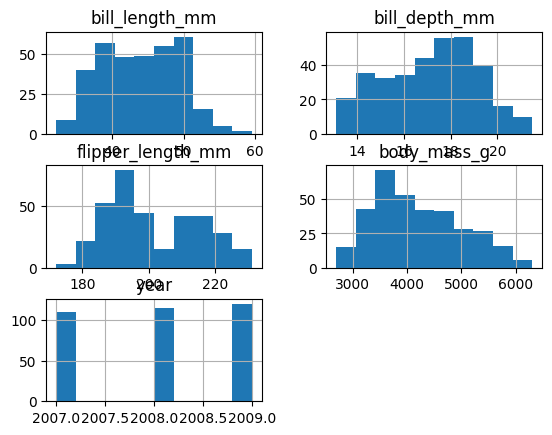

In [7]:
penguins_df.hist()

<Axes: xlabel='species', ylabel='flipper_length_mm'>

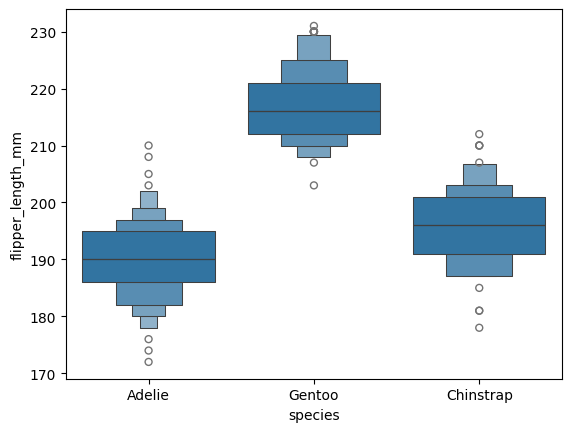

In [17]:
import seaborn as sns
import matplotlib as plt
sns.boxenplot(x='species', y='flipper_length_mm',data=penguins_df)

<Axes: xlabel='species', ylabel='bill_length_mm'>

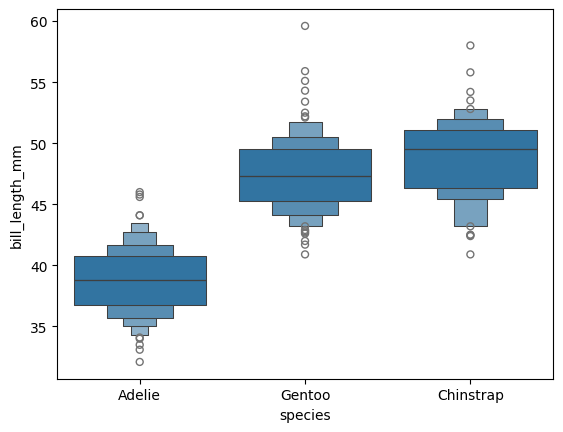

In [29]:
sns.boxenplot(x='species', y='bill_length_mm',data=penguins_df)

<Axes: xlabel='species', ylabel='year'>

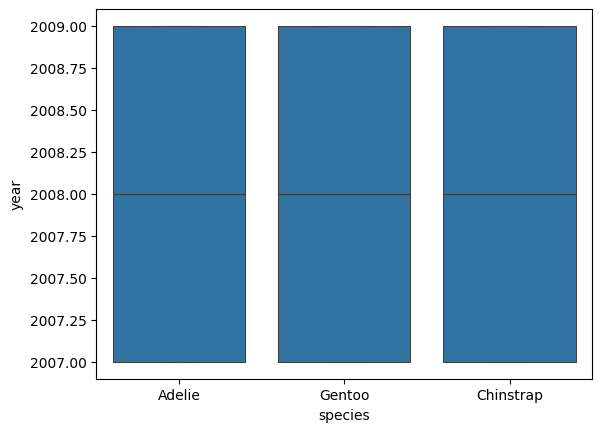

In [20]:
sns.boxenplot(x='species', y='year',data=penguins_df)

In [26]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
gender_one_hot = cat_encoder.fit_transform(penguins_df[['sex']])

In [27]:
gender_one_hot.toarray()

array([[0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       ...,
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.]], shape=(344, 3))

In [31]:
penguins_df['island'].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

In [38]:
penguins_df.groupby(['island','species']).size()

island     species  
Biscoe     Adelie        44
           Gentoo       124
Dream      Adelie        56
           Chinstrap     68
Torgersen  Adelie        52
dtype: int64

In [ ]:
penguins_df.head()